In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np
import scipy.stats as stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from summarytools import dfSummary 
# modun vẽ biểu đồ
from chart_style import *

import joblib
# model
best_lr_model = joblib.load('best_lr_model.pkl')

In [ ]:
# import dữ liệu đã scale để cho vào mô hình đã huấn luyện 
import data_pipeline as dp
df = dp.load_clustering_data("data_raw.csv")
df.head()

,User_ID,Age,Gender,Income_Category,is_income_unknown,User_Level,Usage_Duration,Services_Used,Months_Inactive,Total_Spending,...,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Education_Level_Doctorate,Education_Level_Graduate,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Education_Level_Unknown,Churn
0,768805383,45,0,2.0,0,0,0.384621,0.763943,-1.327136,-0.959707,...,1,0,0,0,0,1,0,0,0,0
1,818770008,49,1,0.0,0,0,1.010715,1.407306,-1.327136,-0.916433,...,0,1,0,0,1,0,0,0,0,0
2,713982108,51,0,3.0,0,0,0.008965,0.120579,-1.327136,-0.740982,...,1,0,0,0,1,0,0,0,0,0
3,769911858,40,1,0.0,0,0,-0.241473,-0.522785,1.641478,-0.951758,...,0,0,1,0,0,1,0,0,0,0
4,709106358,40,0,2.0,0,0,-1.869317,0.763943,-1.327136,-1.056263,...,1,0,0,0,0,0,0,1,0,0


In [4]:
features = ['Usage_Duration',
 'Services_Used',
 'Months_Inactive',
 'Total_Transaction',
 'Income_Category',
 'User_Level',
 'is_income_unknown',
 'Churn'
 ]

In [5]:
#Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X = df[features].drop('Churn', axis=1)  
y = df['Churn']  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **1. Dự báo churn tương lai**

In [6]:
# lọc những khách hàng hiện tại (Churn = 0) và dự đoán xác suất rời đi của họ
df_active = df[df["Churn"] == 0].copy()
# Dự đoán xác suất rời đi (churn) cho những khách hàng hiện tại
df_active["churn_prob"] = best_lr_model.predict_proba(df_active[features].drop(columns=['Churn']))[:,1]
    
# Đặt ngưỡng để phân loại khách hàng có nguy cơ rời đi hay không
threshold = 0.3
df_active["pred_churn"] = (df_active["churn_prob"] > threshold).astype(int)

In [7]:
df_active.head(10)

,User_ID,Age,Gender,Income_Category,is_income_unknown,User_Level,Usage_Duration,Services_Used,Months_Inactive,Total_Spending,...,Marital_Status_Unknown,Education_Level_Doctorate,Education_Level_Graduate,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Education_Level_Unknown,Churn,churn_prob,pred_churn
0,768805383,45,0,2.0,0,0,0.384621,0.763943,-1.327136,-0.959707,...,0,0,0,1,0,0,0,0,0.382832,1
1,818770008,49,1,0.0,0,0,1.010715,1.407306,-1.327136,-0.916433,...,0,0,1,0,0,0,0,0,0.463752,1
2,713982108,51,0,3.0,0,0,0.008965,0.120579,-1.327136,-0.740982,...,0,0,1,0,0,0,0,0,0.801015,1
3,769911858,40,1,0.0,0,0,-0.241473,-0.522785,1.641478,-0.951758,...,1,0,0,1,0,0,0,0,0.973974,1
4,709106358,40,0,2.0,0,0,-1.869317,0.763943,-1.327136,-1.056263,...,0,0,0,0,0,1,0,0,0.686971,1
5,713061558,44,0,1.0,0,0,0.008965,-0.522785,-1.327136,-0.976192,...,0,0,1,0,0,0,0,0,0.849831,1
6,810347208,51,0,4.0,0,2,1.261152,1.407306,-1.327136,-0.904952,...,0,0,0,0,0,0,1,0,0.403176,1
7,818906208,32,0,2.0,0,1,-1.118005,-1.166148,-0.337598,-0.843721,...,1,0,0,1,0,0,0,0,0.868462,1
8,710930508,37,0,2.0,0,0,0.008965,0.763943,-0.337598,-0.899064,...,0,0,0,0,0,1,0,0,0.786398,1
9,719661558,48,0,3.0,0,0,0.008965,1.407306,0.651940,-0.872275,...,0,0,1,0,0,0,0,0,0.675393,1


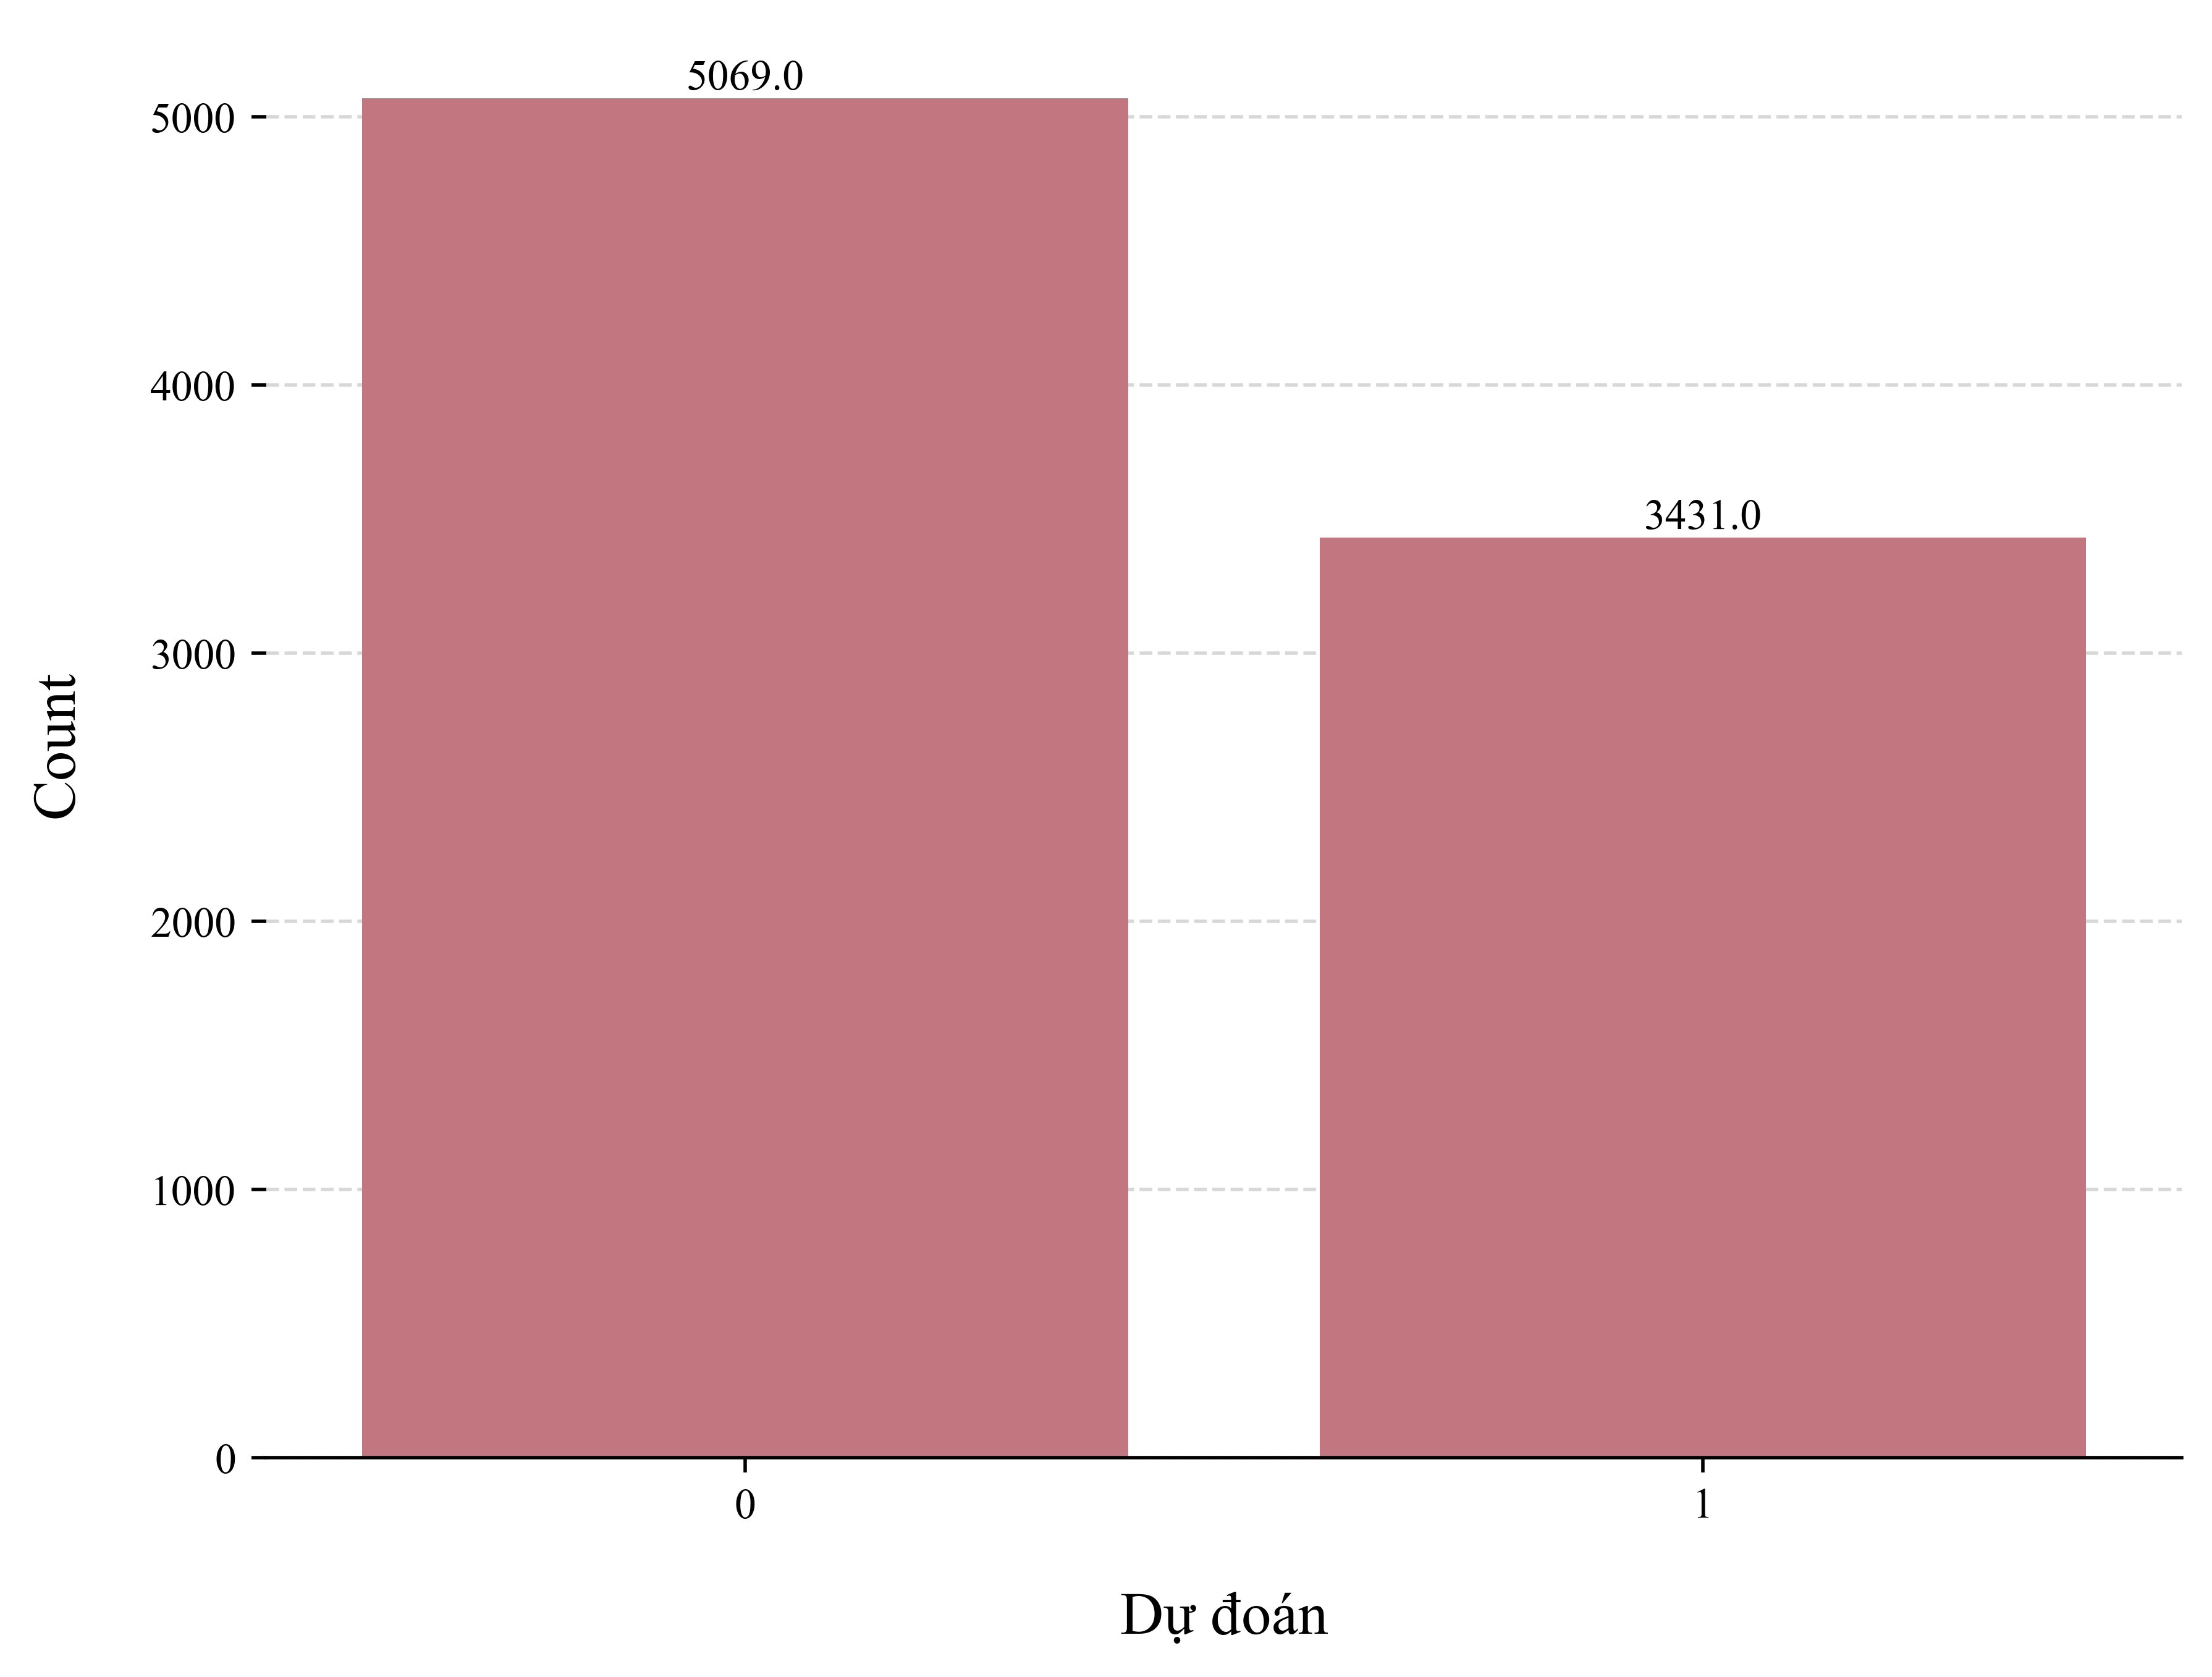

In [8]:
#biểu đồ phân phối khách hàng ở lại và khách hàng có nguy cơ rời đi
fig, ax = plt.subplots(figsize=(8, 6), dpi=500)
sns.countplot(x='pred_churn', data=df_active, color= my_pink, ax=ax)
set_label(ax, xlabel='Dự đoán', ylabel='Count')
set_spines(ax, spines=['top', 'right', 'left'])
# hiện thị số lượng trên mỗi cột
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=10, fontname='Times New Roman', color='black')
# Lưới mờ giúp so sánh giá trị dễ dàng nhưng không làm rối mắt
ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True) # Đẩy lưới ra phía sau cùng
plt.show()  

Từ mối quan hệ tương quan giữa các biến, ta thấy Total_Transaction và Months_Inactive là 2 biến có ảnh hưởng mạnh nhất đến tỷ lệ Churn của khách hàng.=> Tạo chiến lược dựa trên 2 đặc điểm này của khách hàng.

> Chiến lược 1: Chương trình "Kích hoạt lại"
- Total_Transaction là biến dự báo mạnh nhất. Khách hàng rời bỏ thường có <span style="color:lightcoral">số lượng giao dịch rất thấp.<span>
- Hệ thống sẽ gửi tặng voucher nhưng kèm điều kiện: "Thực hiện 3 giao dịch trong tuần này để nhận hoàn tiền 20%". Việc này ép khách hàng phải quay lại tạo thói quen giao dịch.
> Chiến lược 2: Cá nhân hóa nội dung theo "Khoảng lặng"
- <span style="color:lightcoral"> Months_Inactive cho thấy một nhóm khách hàng không rời đi ngay mà họ "im lặng" dần.<span>
- Thay vì gửi các email quảng cáo đại trà (mass marketing) mà họ đã lờ đi bấy lâu, sử dụng chiến thuật "Reminder of Value" (Nhắc nhớ giá trị). Gửi thông điệp dựa trên danh mục họ từng dùng nhiều nhất trước đó: "Đã 2 tháng rồi bạn chưa dùng dịch vụ [X], chúng tôi vừa cập nhật ưu đãi dành riêng cho bạn".

# **2. Kiểm định chiến dịch**

## **Kiểm định sự khác biệt giữa các Chiến dịch**

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency

# 1. Chuẩn bị dữ liệu nhóm nguy cơ cao
# Giả sử df_active là DataFrame của bạn
high_risk = df_active[df_active["pred_churn"] == 1].copy()

# 2. Chia nhóm theo tỉ lệ: 10% Control - 30% Strategy 1 - 30% Strategy 2 - 30% Strategy 1 + Strategy 2
# Bước 1: Tách 10% làm Control
control_group, strategy_group = train_test_split(
    high_risk, test_size=0.9, random_state=42
)

# Bước 2: Chia 90% pool thành 3 nhóm bằng nhau (mỗi nhóm chiếm 1/3 của 90% = 30% tổng)
# Đầu tiên lấy ra 1/3 (tương ứng Strategy 1)
strat_1_group, temp_pool = train_test_split(
    strategy_group, train_size=1/3, random_state=42
)

# Sau đó chia đôi phần còn lại (tương ứng Strategy 2 và Strategy 1+2)
strat_2_group, strat_1_2_group = train_test_split(
    temp_pool, train_size=0.5, random_state=42
)

print(f"Kích thước nhóm Control: {len(control_group)}")
print(f"Kích thước nhóm Strategy 1: {len(strat_1_group)}")
print(f"Kích thước nhóm Strategy 2: {len(strat_2_group)}")
print(f"Kích thước nhóm Strategy 1 + Strategy 2: {len(strat_1_2_group)}")

# --- GIẢ LẬP KẾT QUẢ (Sau khi chạy chiến dịch 1 tháng) ---
# Trong thực tế, bạn sẽ lấy dữ liệu thực tế sau chiến dịch để merge vào đây.
# Giả sử: Control churn 80%, Strat 1 churn 65%, Strat 2 churn 70%, Strat 1 + Strat 2 churn 70%
np.random.seed(42)
control_group['actual_churn'] = np.random.choice([0, 1], size=len(control_group), p=[0.2, 0.8])
strat_1_group['actual_churn'] = np.random.choice([0, 1], size=len(strat_1_group), p=[0.35, 0.65])
strat_2_group['actual_churn'] = np.random.choice([0, 1], size=len(strat_2_group), p=[0.3, 0.7])
strat_1_2_group['actual_churn'] = np.random.choice([0, 1], size=len(strat_1_2_group), p=[0.3, 0.7])

# 3. Phân tích kết quả
def analyze_ab_test(groups, group_names):
    results = []
    for group, name in zip(groups, group_names):
        churn_count = group['actual_churn'].sum()
        total = len(group)
        churn_rate = churn_count / total
        results.append([name, churn_count, total - churn_count, total, churn_rate])
    
    summary_df = pd.DataFrame(results, columns=['Group', 'Churn', 'Stay', 'Total', 'Churn_Rate'])
    return summary_df

summary = analyze_ab_test([control_group, strat_1_group, strat_2_group, strat_1_2_group], 
                          ['Control', 'Strategy_1', 'Strategy_2', 'Strategy_1_2'])
print("\nBảng tổng hợp kết quả:")
print(summary)

# 4. Kiểm định Chi-square để xem sự khác biệt có ý nghĩa thống kê không
# Chúng ta so sánh bảng tần suất (Contingency Table)
contingency_table = summary[['Churn', 'Stay']].values
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nKiểm định Chi-square toàn cục:")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("=> Kết luận: Có sự khác biệt đáng kể giữa các nhóm.")
else:
    print("=> Kết luận: Không có sự khác biệt có ý nghĩa thống kê giữa các nhóm.")



Kích thước nhóm Control: 343
Kích thước nhóm Strategy 1: 1029
Kích thước nhóm Strategy 2: 1029
Kích thước nhóm Strategy 1 + Strategy 2: 1030

Bảng tổng hợp kết quả:
          Group  Churn  Stay  Total  Churn_Rate
0       Control    266    77    343    0.775510
1    Strategy_1    666   363   1029    0.647230
2    Strategy_2    727   302   1029    0.706511
3  Strategy_1_2    713   317   1030    0.692233

Kiểm định Chi-square toàn cục:
P-value: 0.0001
=> Kết luận: Có sự khác biệt đáng kể giữa các nhóm.


## **Kiểm định hiệu quả Chiến dịch 1**

In [10]:
#thực hiên kiểm định cặp giữa Strategy 1 và Control
# Tạo bảng tần suất cho Strategy 1 và Control
contingency_table_strat1_control = np.array([
    [strat_1_group['actual_churn'].sum(), len(strat_1_group) - strat_1_group['actual_churn'].sum()],
    [control_group['actual_churn'].sum(), len(control_group) - control_group['actual_churn'].sum()]
])
chi2, p, dof, expected = chi2_contingency(contingency_table_strat1_control)
print("\n" + "="*50)
print(f"KẾT QUẢ KIỂM ĐỊNH CẶP GIỮA STRATEGY 1 VÀ CONTROL")
print("="*50)
print(f"\nKiểm định Chi-square giữa Strategy 1 và Control:")
print(f"P-value: {p:.4f}")      
print (f"Chi2: {chi2:.4f}, DOF: {dof}")
if p < 0.05:
    print("=> Kết luận: Strategy 1 có hiệu quả đáng kể so với Control.")
else:
    print("=> Kết luận: Strategy 1 không có hiệu quả đáng kể so với Control.")  



KẾT QUẢ KIỂM ĐỊNH CẶP GIỮA STRATEGY 1 VÀ CONTROL

Kiểm định Chi-square giữa Strategy 1 và Control:
P-value: 0.0000
Chi2: 18.8474, DOF: 1
=> Kết luận: Strategy 1 có hiệu quả đáng kể so với Control.


## **Kiểm định hiệu quả Chiến dịch 2**

In [11]:
#thực hiên kiểm định cặp giữa Strategy 2 và Control
contingency_table_strat2_control = np.array([
    [strat_2_group['actual_churn'].sum(), len(strat_2_group) - strat_2_group['actual_churn'].sum()],
    [control_group['actual_churn'].sum(), len(control_group) - control_group['actual_churn'].sum()]
])
chi2, p, dof, expected = chi2_contingency(contingency_table_strat2_control)
print("\n" + "="*50)
print(f"KẾT QUẢ KIỂM ĐỊNH CẶP GIỮA STRATEGY 2 VÀ CONTROL")
print("="*50)
print(f"\nKiểm định Chi-square giữa Strategy 2 và Control:")
print(f"P-value: {p:.4f}")      
print (f"Chi2: {chi2:.4f}, DOF: {dof}")
if p < 0.05:
    print("=> Kết luận: Strategy 2 có hiệu quả đáng kể so với Control.")
else:
    print("=> Kết luận: Strategy 2 không có hiệu quả đáng kể so với Control.")  


KẾT QUẢ KIỂM ĐỊNH CẶP GIỮA STRATEGY 2 VÀ CONTROL

Kiểm định Chi-square giữa Strategy 2 và Control:
P-value: 0.0162
Chi2: 5.7855, DOF: 1
=> Kết luận: Strategy 2 có hiệu quả đáng kể so với Control.


## **Kiểm định hiệu quả khi kết hợp Chiến dịch 1+2**

In [12]:
#thực hiên kiểm định cặp giữa Strategy 1 + Strategy 2 và Control
contingency_table_strat1_2_control = np.array([
    [strat_1_2_group['actual_churn'].sum(), len(strat_1_2_group) - strat_1_2_group['actual_churn'].sum()],
    [control_group['actual_churn'].sum(), len(control_group) - control_group['actual_churn'].sum()]
])
chi2, p, dof, expected = chi2_contingency(contingency_table_strat1_2_control)
print("\n" + "="*70)
print(f"KẾT QUẢ KIỂM ĐỊNH CẶP GIỮA STRATEGY 1 + STRATEGY 2 VÀ CONTROL")
print("="*70)
print(f"\nKiểm định Chi-square giữa Strategy 1 + Strategy 2 và Control:")
print(f"P-value: {p:.4f}")      
print (f"Chi2: {chi2:.4f}, DOF: {dof}")
if p < 0.05:
    print("=> Kết luận: Strategy 1 + Strategy 2 có hiệu quả đáng kể so với Control.")
else:
    print("=> Kết luận: Strategy 1 + Strategy 2 không có hiệu quả đáng kể so với Control.")  


KẾT QUẢ KIỂM ĐỊNH CẶP GIỮA STRATEGY 1 + STRATEGY 2 VÀ CONTROL

Kiểm định Chi-square giữa Strategy 1 + Strategy 2 và Control:
P-value: 0.0039
Chi2: 8.3189, DOF: 1
=> Kết luận: Strategy 1 + Strategy 2 có hiệu quả đáng kể so với Control.


# **So sánh hiệu quả giữa các nhóm**

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from itertools import combinations

def perform_statistical_test(summary_df, alpha=0.05):
    """
    Thực hiện kiểm định Chi-square toàn cục và so sánh cặp giữa các nhóm.
    """
    print("\n" + "="*50)
    print(" PHÂN TÍCH CHI TIẾT KẾT QUẢ A/B TESTING ")
    print("="*50)

    # 3. So sánh cặp (Pairwise Comparison) với hiệu chỉnh Bonferroni
    all_groups = summary_df['Group'].unique()
    pairs = list(combinations(all_groups, 2)) 
    
    # Hiệu chỉnh Alpha để tránh sai số loại I (Dương tính giả) khi thực hiện nhiều phép thử
    bonferroni_alpha = alpha / len(pairs)
    
    posthoc_results = []
    for g1, g2 in pairs:
        # Lấy dữ liệu của 2 nhóm
        subset = summary_df[summary_df['Group'].isin([g1, g2])]
        table = subset[['Churn', 'Stay']].values
        
        _, p_val, _, _ = chi2_contingency(table)
        
        posthoc_results.append({
            'Comparison': f"{g1} vs {g2}",
            'P-Value': p_val,
            'Significant': p_val < bonferroni_alpha
        })
    
    comparison_df = pd.DataFrame(posthoc_results)
    
    print(f"\nKết quả so sánh cặp (Alpha hiệu chỉnh: {bonferroni_alpha:.4f}):")
    print(comparison_df)
    
    return comparison_df

# Sử dụng bảng 'summary' bạn đã tạo ở trên
comparison_results = perform_statistical_test(summary)



 PHÂN TÍCH CHI TIẾT KẾT QUẢ A/B TESTING 

Kết quả so sánh cặp (Alpha hiệu chỉnh: 0.0083):
                   Comparison   P-Value  Significant
0       Control vs Strategy_1  0.000014         True
1       Control vs Strategy_2  0.016159        False
2     Control vs Strategy_1_2  0.003923         True
3    Strategy_1 vs Strategy_2  0.004683         True
4  Strategy_1 vs Strategy_1_2  0.033660        False
5  Strategy_2 vs Strategy_1_2  0.510269        False


# **So sánh tỷ lệ Churn**

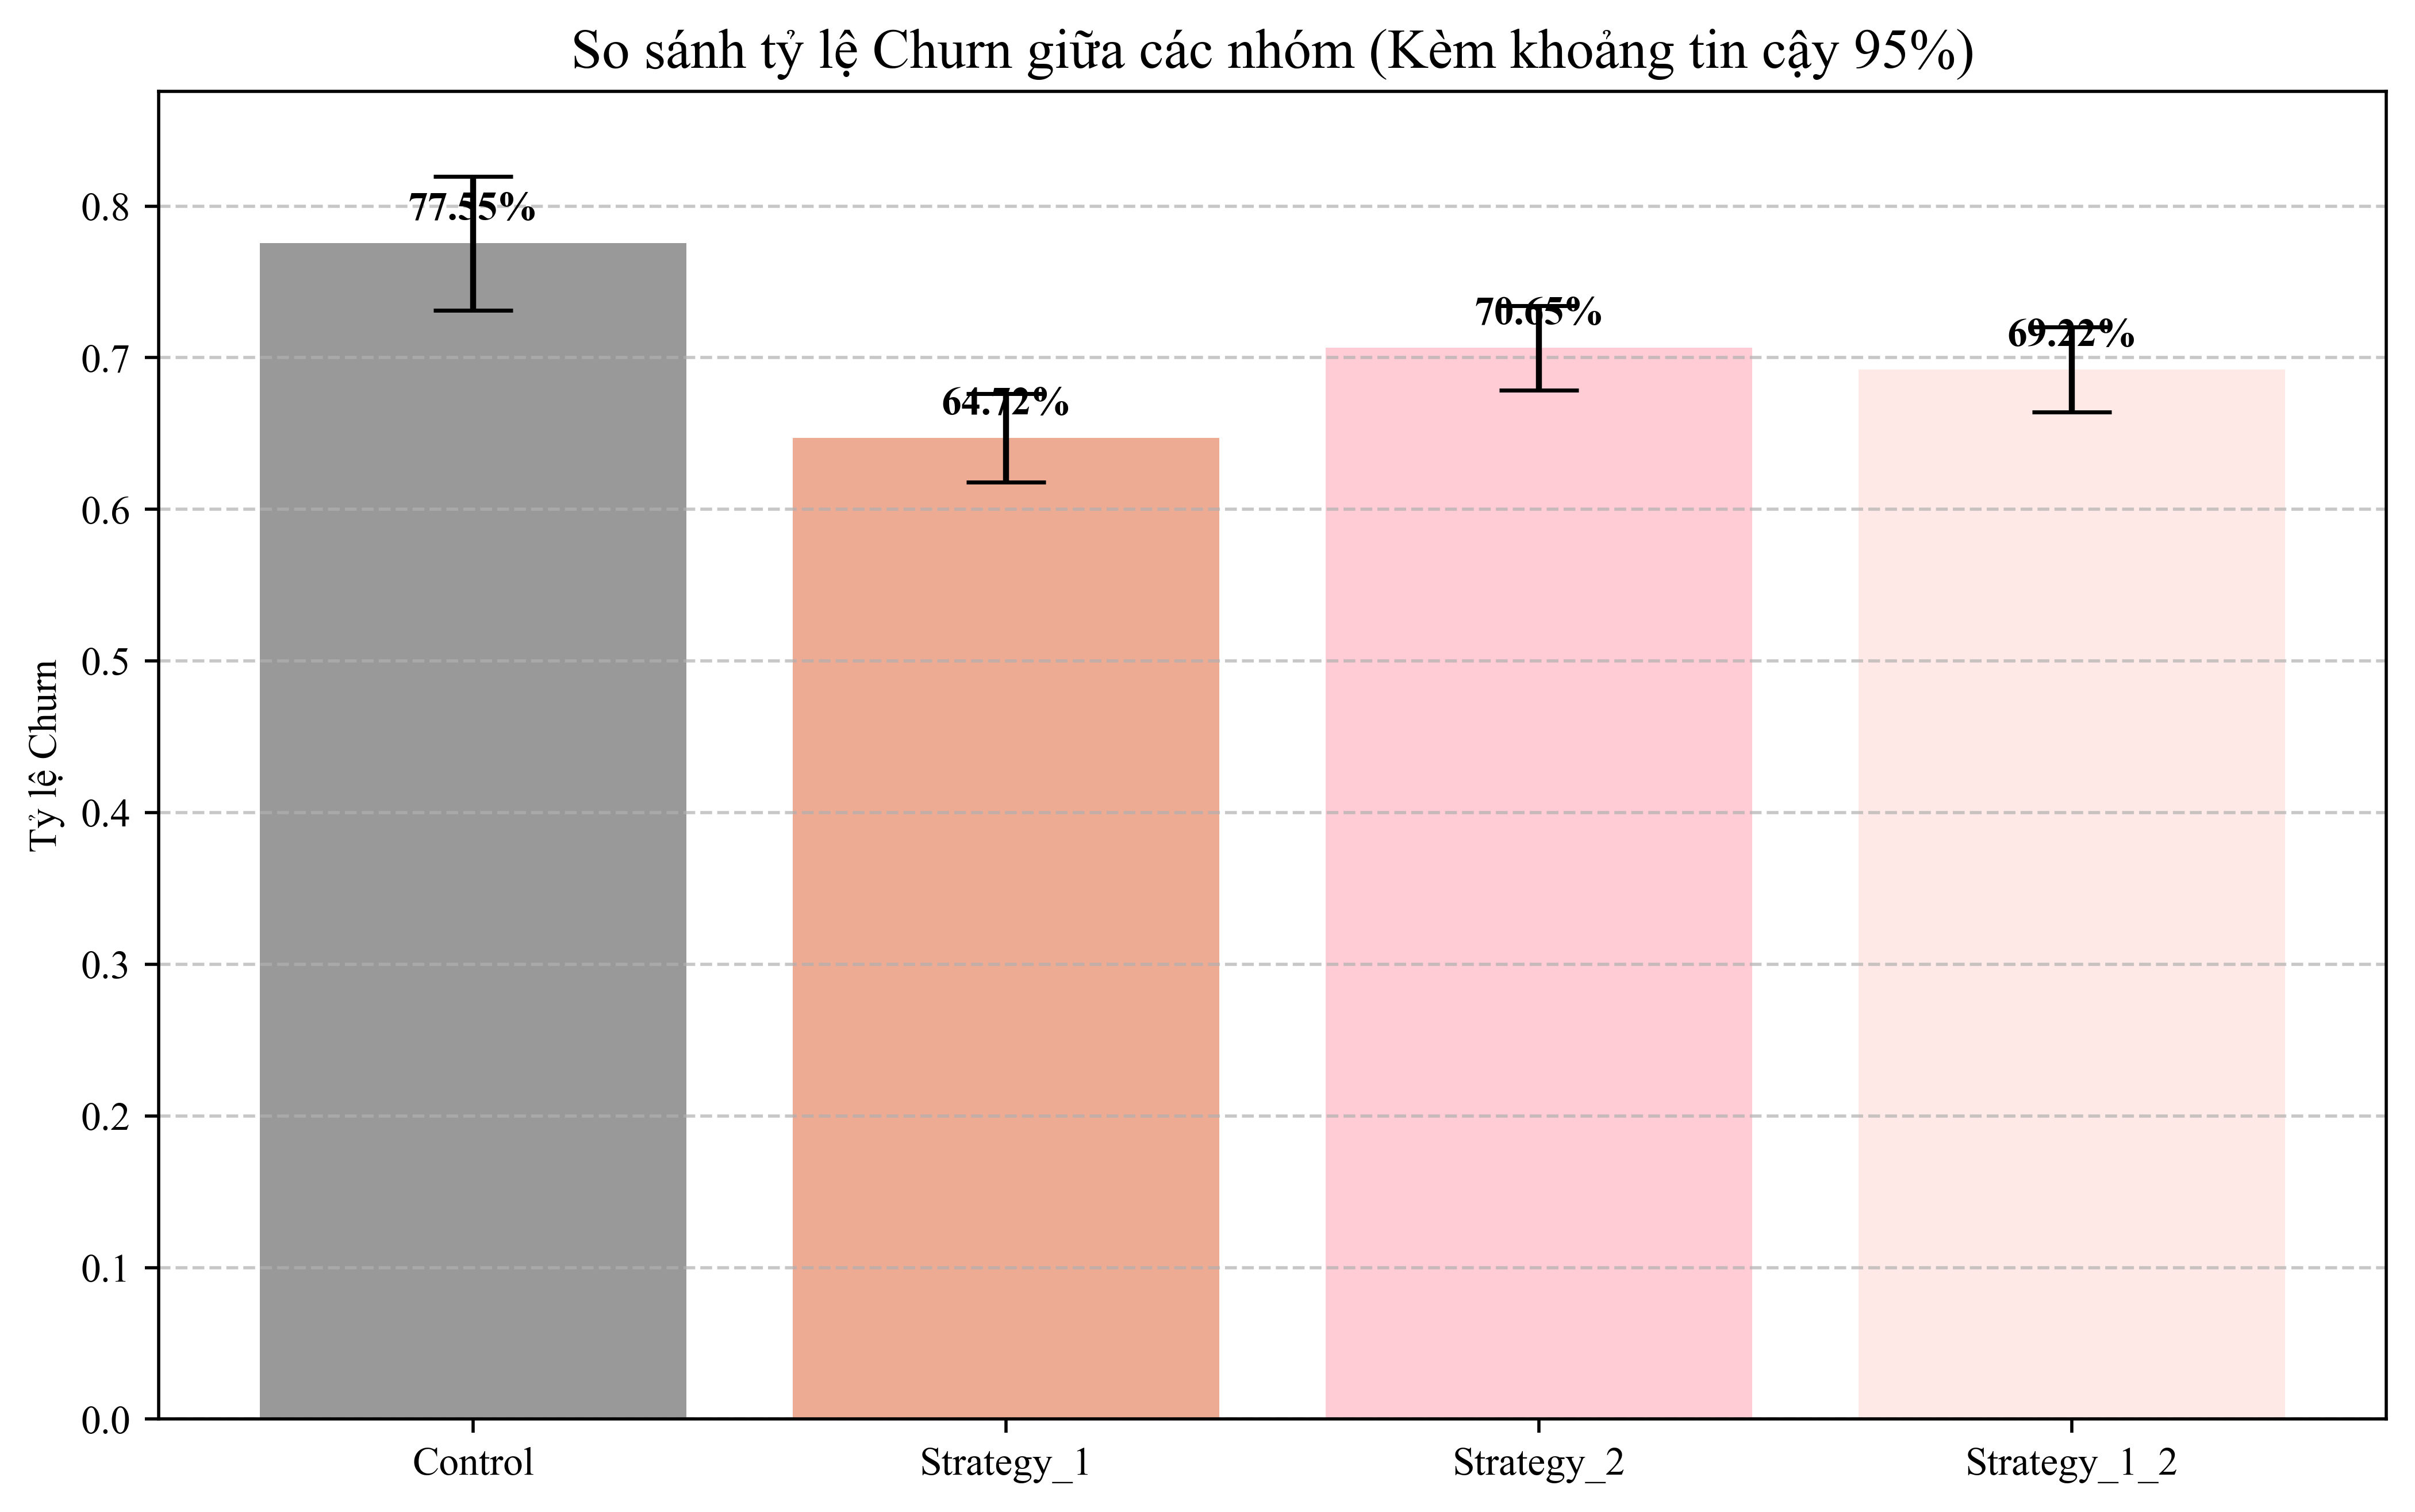

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ab_test_results(summary_df):
    """
    Trực quan hóa tỷ lệ Churn kèm theo khoảng sai số 95%.
    """
    fig, ax = plt.subplots(figsize=(10, 6), dpi=500)
    
    # Tính sai số tiêu chuẩn (Standard Error) cho tỷ lệ phần trăm
    # SE = sqrt( p * (1-p) / n )
    summary_df['SE'] = np.sqrt(
        summary_df['Churn_Rate'] * (1 - summary_df['Churn_Rate']) / summary_df['Total']
    )
    
    # Vẽ biểu đồ cột
    bars = plt.bar(summary_df['Group'], summary_df['Churn_Rate'], 
                   yerr=summary_df['SE']*1.96, # 1.96 cho khoảng tin cậy 95%
                   capsize=10, color=['gray','darksalmon','pink', 'mistyrose'], alpha=0.8)
    
    # Thêm nhãn tỷ lệ phần trăm trên đầu cột
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
                 f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

    ax.set_title('So sánh tỷ lệ Churn giữa các nhóm (Kèm khoảng tin cậy 95%)', fontsize=14)
    ax.set_ylabel('Tỷ lệ Churn')
    ax.set_ylim(0, summary_df['Churn_Rate'].max() + 0.1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Gọi hàm với dataframe summary của bạn
plot_ab_test_results(summary)

**So sánh Strategy 1 vs Control:**
- Hai khoảng sai số (hai cái "râu") của nhóm Control và Strategy 1 không hề chồng lấp (overlap) lên nhau.
- Kết luận: Strategy 1 có hiệu quả thực sự.

**So sánh Strategy 2 vs Control:**
- Khoảng sai số của Strategy 2 hơi chồng lấp nhẹ với dải dưới của Control. Hiệu quả có thể có nhưng ít và không mạnh mẽ bằng Strategy 1.

**So sánh Strategy 1 + 2 vs Control**
- Strategy_1_2 đạt 69.62%, thấp hơn đáng kể so với nhóm Control (78.10%) nhưng lại kém hơn Strategy 1 (64.84%).

**Strategy 1** 

Mức giảm tuyệt đối: 77.18%−64.61%=12.57% (nghĩa là cứ 100 người thì giữ chân thêm được khoảng 12-13 người so với việc không làm gì).